In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

CONFIG = {
    'good_dir': r'D:\_Dataset\M6_29Sep2023\Good',
    'bad_dir': r'D:\_Dataset\M6_29Sep2023\Bad',
    'img_size': (500, 500),
    'batch_size': 8,
    'epochs': 50,
    'learning_rate': 1e-4,
    'model_save_path': 'models/pandora_deep_v2.pth',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

device = torch.device(CONFIG['device'])
print(f"Using device: {device}")

Using device: cuda


In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels)
        )
    def forward(self, x): return F.relu(x + self.conv(x))

class PandoraDeepV2(nn.Module):
    def __init__(self):
        super(PandoraDeepV2, self).__init__()
        
        # 4 Specialized Paths for 500x500 details
        self.path1x1 = nn.Conv2d(3, 16, kernel_size=1) # Color/Intensity
        self.path3x3 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # Micro-scratches
        self.path5x5 = nn.Conv2d(3, 16, kernel_size=5, padding=2) # Medium Texture
        self.path_dilated = nn.Conv2d(3, 16, kernel_size=3, padding=2, dilation=2) # Context
        
        self.bn_init = nn.BatchNorm2d(64)
        self.register_buffer('path_importance', torch.zeros(4))

        # Funnel: Reduce resolution to 250x250 to save 3060Ti VRAM
        self.downsample = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True)
        )

        # Deep Residual Backbone for 'Big' defects
        self.res_layers = nn.Sequential(
            ResidualBlock(128),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1), # to 125x125
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            ResidualBlock(256),
            ResidualBlock(256)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, 64), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(64, 1)
            #nn.Sigmoid()
        )

    def forward(self, x, track_importance=False):
        # Path features
        outs = [self.path1x1(x), self.path3x3(x), self.path5x5(x), self.path_dilated(x)]
        if track_importance:
            for i, o in enumerate(outs): self.path_importance[i] += o.abs().mean().detach()
        
        x = torch.cat(outs, dim=1)
        x = F.relu(self.bn_init(x))
        x = self.downsample(x)
        x = self.res_layers(x)
        return self.classifier(x)

def analyze_paths(model):
    paths_desc = ["1x1 Color", "3x3 Local", "5x5 Texture", "3x3 Dilated"]
    importance = model.path_importance.cpu().numpy()
    if importance.sum() == 0: return
    importance = (importance / importance.sum()) * 100
    plt.bar(paths_desc, importance, color='crimson')
    plt.title("4-Path Signal Strength (%)"); plt.show()

In [7]:
class ImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths, self.labels, self.transform = image_paths, labels, transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.image_paths[idx]), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (CONFIG['img_size'][1], CONFIG['img_size'][0]))
        if self.transform: img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

def get_data():
    def get_files(d, l): 
        p = [str(f) for f in Path(d).glob('*') if f.suffix.lower() in {'.jpg', '.png', '.bmp'}]
        return p, [l]*len(p)
    g_p, g_l = get_files(CONFIG['good_dir'], 1)
    b_p, b_l = get_files(CONFIG['bad_dir'], 0)
    return train_test_split(g_p + b_p, g_l + b_l, test_size=0.2, random_state=42)

Epoch 1: 100%|██████████| 60/60 [00:14<00:00,  4.26it/s]


Val Acc: 0.4833 | Recall (Bad): 1.0000 | LR: 0.000100
  --> Saved Best Model (0.4833)


Epoch 2: 100%|██████████| 60/60 [00:13<00:00,  4.45it/s]


Val Acc: 0.4833 | Recall (Bad): 1.0000 | LR: 0.000100


Epoch 3: 100%|██████████| 60/60 [00:13<00:00,  4.43it/s]


...

Val Acc: 0.9833 | Recall (Bad): 1.0000 | LR: 0.000000


Epoch 49: 100%|██████████| 60/60 [00:13<00:00,  4.32it/s]


Val Acc: 0.9917 | Recall (Bad): 1.0000 | LR: 0.000000


Epoch 50: 100%|██████████| 60/60 [00:13<00:00,  4.32it/s]


Val Acc: 0.9833 | Recall (Bad): 1.0000 | LR: 0.000000


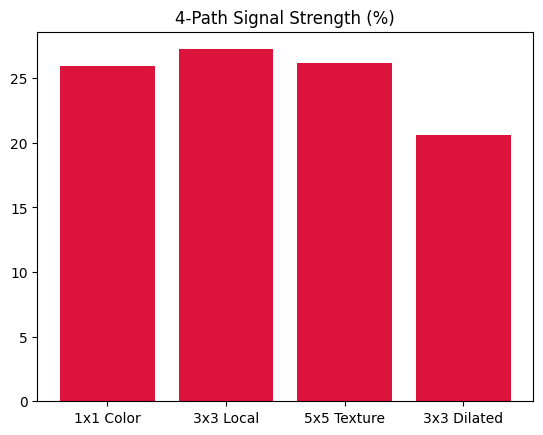

In [9]:
train_p, val_p, train_l, val_l = get_data()

train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(ImageDataset(train_p, train_l, train_tf), batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(ImageDataset(val_p, val_l, val_tf), batch_size=CONFIG['batch_size'])

model = PandoraDeepV2().to(device)
#optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
criterion = nn.BCEWithLogitsLoss() # Combined Sigmoid + BCE
# 2. Update the Scaler (Modern PyTorch 2.x syntax)
scaler = torch.amp.GradScaler('cuda')

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2) # Anchor weights
# Drops LR by 10x if accuracy stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

best_val_acc = 0

for epoch in range(CONFIG['epochs']):
    model.train(); train_loss = 0
    for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, lbls = imgs.to(device), lbls.to(device).unsqueeze(1)
        smooth_lbls = lbls * 0.9 + 0.05
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            logits = model(imgs)
            loss = criterion(logits, smooth_lbls)
        
        scaler.scale(loss).backward()
        # Gradient Clipping: Prevents the "50% accuracy bounce"
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update()
        train_loss += loss.item()

    model.eval(); all_preds = []; all_labels = []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            logits = model(imgs.to(device), track_importance=True)
            out = torch.sigmoid(logits) 
            all_preds.extend(out.cpu().numpy())
            all_labels.extend(lbls.numpy())
    
    binary_preds = [1 if p > 0.85 else 0 for p in all_preds]
    acc = accuracy_score(all_labels, binary_preds)
    rec = recall_score(all_labels, binary_preds, pos_label=0)
    
    # Update LR based on accuracy
    scheduler.step(acc)
    
    print(f"Val Acc: {acc:.4f} | Recall (Bad): {rec:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if acc > best_val_acc:
        best_val_acc = acc
        torch.save(model.state_dict(), CONFIG['model_save_path'])
        print(f"  --> Saved Best Model ({acc:.4f})")

analyze_paths(model)

In [11]:
import time
import torch.onnx

def benchmark_and_export():
    # 1. Initialize and Load Weights
    model = PandoraDeepV2().to('cpu') # Start on CPU for first test
    model.load_state_dict(torch.load(CONFIG['model_save_path'], map_location='cpu'))
    model.eval()

    # Create dummy input based on your 500x500 config
    dummy_input = torch.randn(1, 3, CONFIG['img_size'][0], CONFIG['img_size'][1])

    # ---------------------------------------------------------
    # BENCHMARK: CPU
    # ---------------------------------------------------------
    print("--- CPU Benchmarking ---")
    with torch.no_grad():
        # Warmup
        for _ in range(5): _ = model(dummy_input)
        
        start_time = time.time()
        for _ in range(20): _ = model(dummy_input)
        cpu_avg = (time.time() - start_time) / 20
    print(f"Average CPU Inference: {cpu_avg*1000:.2f} ms")

    # ---------------------------------------------------------
    # BENCHMARK: GPU (RTX 3060 Ti)
    # ---------------------------------------------------------
    if torch.cuda.is_available():
        print("\n--- GPU Benchmarking ---")
        model_gpu = model.to('cuda')
        dummy_gpu = dummy_input.to('cuda')
        
        with torch.no_grad():
            # Warmup (Crucial for GPU kernels to initialize)
            for _ in range(10): _ = model_gpu(dummy_gpu)
            
            torch.cuda.synchronize() # Wait for GPU to be ready
            start_time = time.time()
            for _ in range(50): _ = model_gpu(dummy_gpu)
            torch.cuda.synchronize() # Wait for all kernels to finish
            gpu_avg = (time.time() - start_time) / 50
        print(f"Average GPU Inference: {gpu_avg*1000:.2f} ms")

    # ---------------------------------------------------------
    # EXPORT TO ONNX
    # ---------------------------------------------------------
    onnx_path = CONFIG['model_save_path'].replace('.pth', '.onnx')
    print(f"\nExporting to {onnx_path}...")
    
    torch.onnx.export(
        model.cpu(),               # Exporting the CPU version is more portable
        dummy_input,               # Shape: (1, 3, 500, 500)
        onnx_path,
        export_params=True,        # Store trained weights inside the file
        opset_version=12,          # Stable version for Windows/OpenVINO
        do_constant_folding=True,  # Optimizes the graph
        input_names=['input'],     # Name for C++ input binding
        output_names=['output'],   # Name for C++ output binding
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
    )
    print("Export Complete!")

benchmark_and_export()

--- CPU Benchmarking ---
Average CPU Inference: 244.53 ms

--- GPU Benchmarking ---
Average GPU Inference: 13.92 ms

Exporting to models/pandora_deep_v2.onnx...


C:\Users\ryuto\AppData\Local\Temp\ipykernel_7172\3977474492.py:51: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0401 23:07:17.834000 7172 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `PandoraDeepV2([...]` with `torch.export.export(..., strict=False)`...


W0401 23:07:18.704000 7172 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


[torch.onnx] Obtain model graph for `PandoraDeepV2([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\ryuto\AppData\Local\Programs\Python\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 12).
Failed to convert the model to the target version 12 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "d:\_Sandbox\VisionDLM\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "d:\_Sandbox\VisionDLM\.venv\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "d:\_Sandbox\VisionDLM\.venv\Lib\site-packages\onnxscript\version

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 15 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
Export Complete!
